# Task 4a: 'Audio Evidence'

In this notebook, we are adding a new feature called **“Audio Evidence”** that looks for 'noises' or particular sounds within the description. 

It is set to <span style="color:green">**True**</span> if we are able to successfully match the text to any auditory description. And <span style="color:red">**False**</span> otherwise.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
haunted_places = pd.read_csv("../data/haunted_places.tsv", sep='\t')

In [7]:
# audio = ["noise", "noises", "sound", "nursery rhymes", "hear", "hearing", "heard", "screams", "shouts"]
audio = [
    "noise", "noises", "sound", "nursery rhymes", 
    "hear", "hearing", "heard", "screams", "shouts",
    'sound of snapping neck', 'footsteps', 'whispers', 'voices', 'crying', 
    'laughter', 'knocking', 'banging', 'chanting', 'howling', 
    'singing', 'breathing', 'growling', 'echoes', 'thumping', 
    'scratching', 'radio static', 'distant talking', 'chains rattling', 
    'moaning', 'muffled voices', 'creaking', 'rustling', 'heartbeat', 
    'gasp', 'wailing', 'rattling', 'bell ringing', 'shuffling', 
    'clanging', 'doors slamming', 'whimpering', 'sirens', 'alarms', 
    'buzzing', 'humming', 'crashing', 'yelling', 
    'clapping', 'dripping water', 'ambient noise', 'unexplained sounds', 
    'phantom noises', 'weeping', 'voices in the dark', 'animal sounds', 
    'death rattle', 'wind howling'
]
haunted_places["Audio Evidence"] = haunted_places["description"].str.contains("|".join(audio), case=False, na=False)

In [8]:
haunted_places.to_csv("../data/haunted_places.tsv", sep='\t', index=False)

# Visualizations
Let's take a look at some of the results. 

The first graph lets us examine the **Presence of Auditory Evidence** within the entire dataset. Based on the graph, we have the following results: 
- Entries with Audio Evidence: 4973 (**45.2%**)
- Entries without Audio Evidence: 6019 (**54.8%**)

The second graph allows us to see the **Top 10 States with Most Haunted Places with Audio Evidence** with the number of of audio evidence per state next to it. 

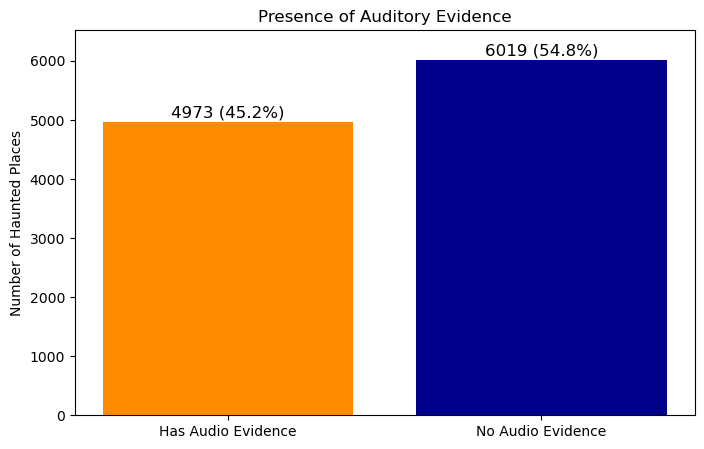

In [13]:
# Count occurrences of True and False
auditory_counts = haunted_places['Audio Evidence'].value_counts()
total_entries = len(haunted_places)

# Reorder the counts so 'Has Audio Evidence' comes first
auditory_counts = auditory_counts[::-1]  # This reverses the order

# Create figure and plot
plt.figure(figsize=(8, 5))
bars = plt.bar(['Has Audio Evidence', 'No Audio Evidence'], auditory_counts, color=['darkorange', 'darkblue'])

# Add text (count + percentage) on top of each bar
for bar, count in zip(bars, auditory_counts):
    percentage = (count / total_entries) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,  # Adjust the +20 for spacing
        f'{count} ({percentage:.1f}%)',
        ha='center', va='bottom', fontsize=12, color='black')  # va='bottom' places text above



# Labels and title
plt.ylabel('Number of Haunted Places')
plt.title('Presence of Auditory Evidence')
plt.ylim(0, max(auditory_counts) + 500)  # Add space for text
plt.show()


/var/folders/z5/vfx1x7n1717bc2w84z8xwftw0000gn/T/ipykernel_4729/1994543678.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='state', data=top10_states, palette='Blues_r')


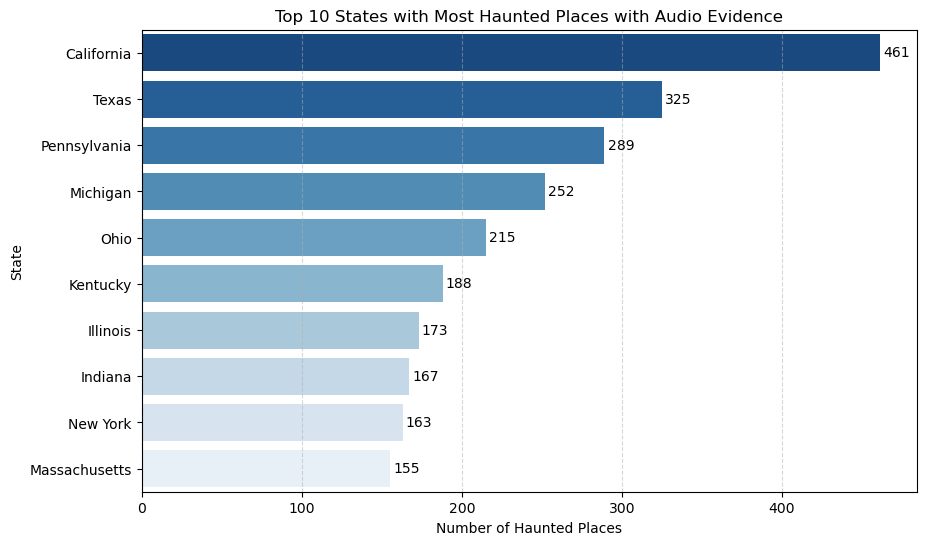

In [83]:
# Filter data to just places with audio evidence
audio_df = haunted_places[haunted_places['Audio Evidence'] == True]

# Group by state and count
state_audio_counts = audio_df['state'].value_counts().reset_index()
state_audio_counts.columns = ['state', 'count']

# Only keep top 10 states
top10_states = state_audio_counts.head(10)

# Plot bar chart (heatmap style color gradient)
plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='state', data=top10_states, palette='Blues_r')

# Add counts on the bars
for index, row in top10_states.iterrows():
    plt.text(row['count'] + 2, index, str(row['count']), color='black', va='center', fontsize=10)

# Add titles and labels
plt.title('Top 10 States with Most Haunted Places with Audio Evidence')
plt.xlabel('Number of Haunted Places')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()
